# Deep Dive into Embeddings and Language Models

This notebook acts as a presentation-style walkthrough connecting classic distributional semantics with modern transformer-based language models.

**Today objectives**

- Understand embeddings as a representation for language.
- Distinguish between static, contextual, token, and sequence-level embeddings.
- Train and evaluate a Word2Vec model on a real dataset.
- Generate contextual embeddings with a transformer and compare them with Word2Vec.
- Observe how embeddings enable similarity search and retrieval for LLM-powered systems.

**What to watch, where to study**

Hugging face courses:

* https://huggingface.co/learn/llm-course/chapter1/1


Andrej Karpathy channel

* Intro to Large Language Models: https://www.youtube.com/watch?v=zjkBMFhNj_g
* Let's build GPT: from scratch, in code, spelled out: https://www.youtube.com/watch?v=kCc8FmEb1nY
* Let's build the GPT Tokenizer: https://www.youtube.com/watch?v=zduSFxRajkE
* Let's reproduce GPT-2 (124M): https://www.youtube.com/watch?v=l8pRSuU81PU
* Deep Dive into LLMs like ChatGPT: https://www.youtube.com/watch?v=7xTGNNLPyMI

Grant Sanderson channel
* Transformers, the tech behind LLMs | Deep Learning Chapter 5: https://youtu.be/wjZofJX0v4M?t=683
* Attention in transformers, step-by-step | Deep Learning Chapter 6: https://www.youtube.com/watch?v=eMlx5fFNoYc

Anthropic description of Mathematical Framwork for Transformers
* https://transformer-circuits.pub/2021/framework/index.html

Jay Alammar
* Hands-On Large Language Models post: https://jalammar.github.io/illustrated-transformer/
* Visualizing A Neural Machine Translation Model: https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/

How token looks like:
* https://tiktokenizer.vercel.app/


## Why embeddings?

- Natural language is discrete, but models operate on numbers.
- Embeddings map symbols to dense vectors where geometric proximity encodes **semantic** or **syntactic** relationships.

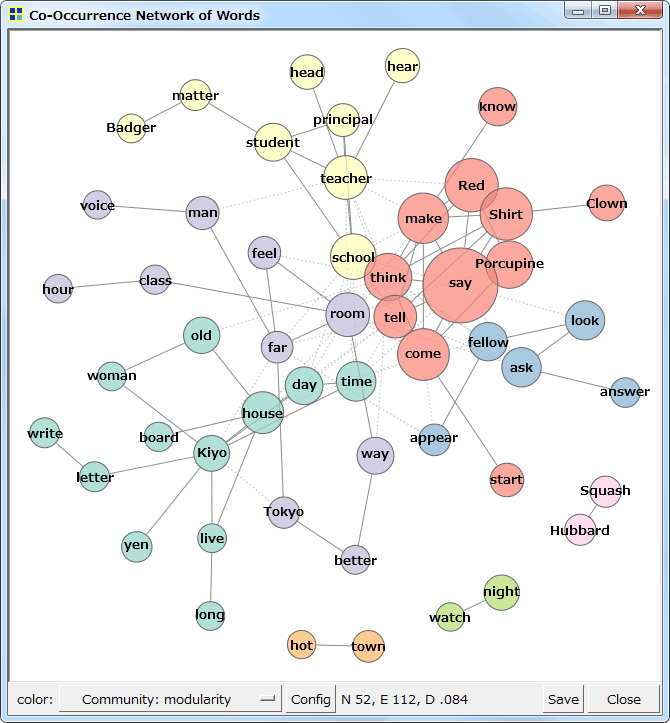

Source: Wiki Co-occurrence network


## Geometry of meaning

- Dimensionality: even 100–768 dimensions capture nuanced relations impossible with sparse one-hot encodings.
- Similarity: cosine similarity and dot products let us measure how related two tokens are.
- Composition: vector arithmetic (e.g., king − man + woman ≈ queen) emerges because the geometry encodes latent attributes.

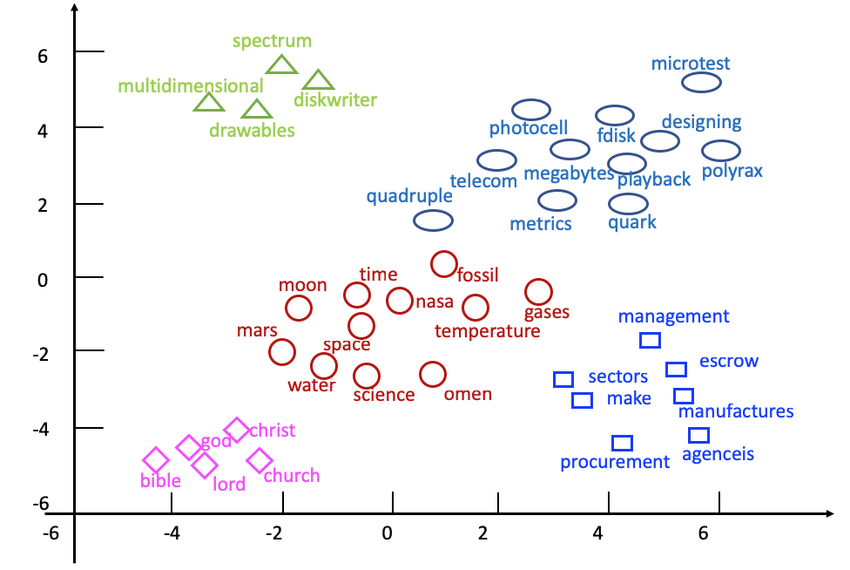

A picture about a 2D projection of embedding clusters 
Source: TMSA: A Mutual Learning Model for Topic Discovery and Word Embedding

## Static vs contextual embeddings

| Aspect | Static (Word2Vec, GloVe) | Contextual (BERT, GPT) |
| --- | --- | --- |
| Representation granularity | One vector per word type | One vector per token occurrence |
| Captures polysemy? | No | Yes |
| Training signal | Local context windows | Bidirectional/self-attentive conditioning |
| Typical use cases | Similarity, analogies, initialization | Downstream fine-tuning, retrieval, generation |

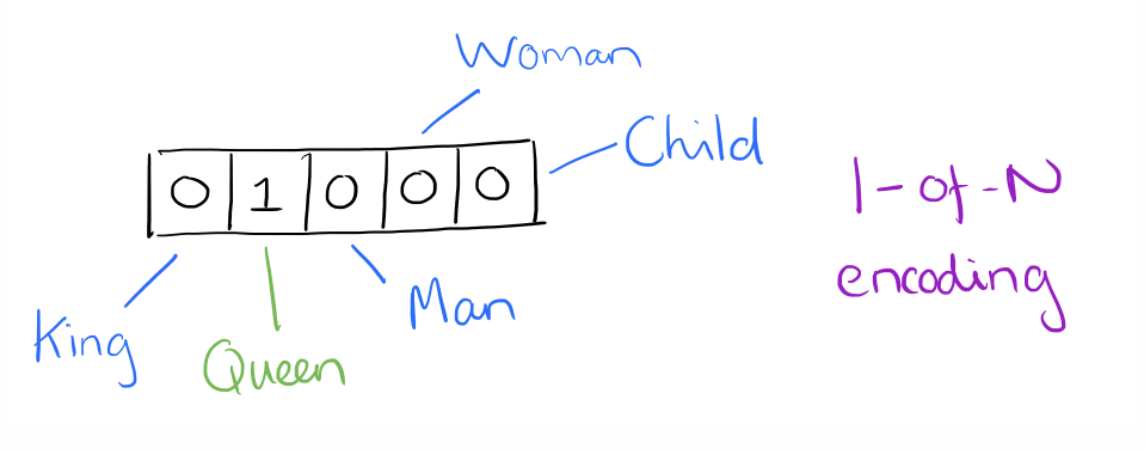

 one-hot encoding

## Word2Vec intuition

- **CBOW** (Continuous Bag of Words): 
    * Predict the centre word from surrounding context.
    * Uses central word as an input to NN and neighbour words as an output.
- **Skip-gram**:
    * Predict surrounding context words from the centre word (performs better on rare words).
    * Uses neighbour words as an input to NN and central word as an output.
- Lightweight neural networks whose hidden layer weights become our embeddings.
- Training objective: maximise probability of observed (word, context) pairs while minimising noise via negative sampling or hierarchical softmax.

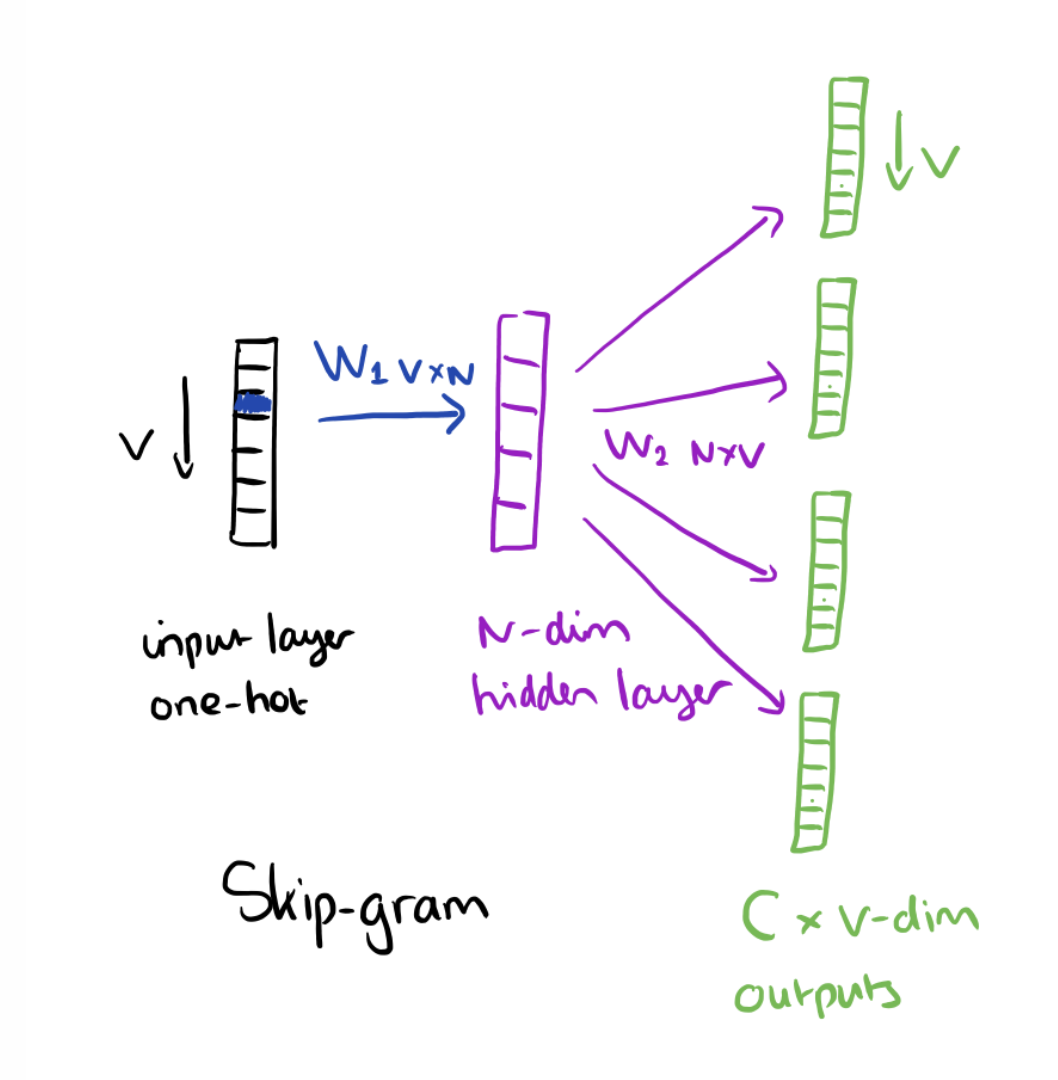

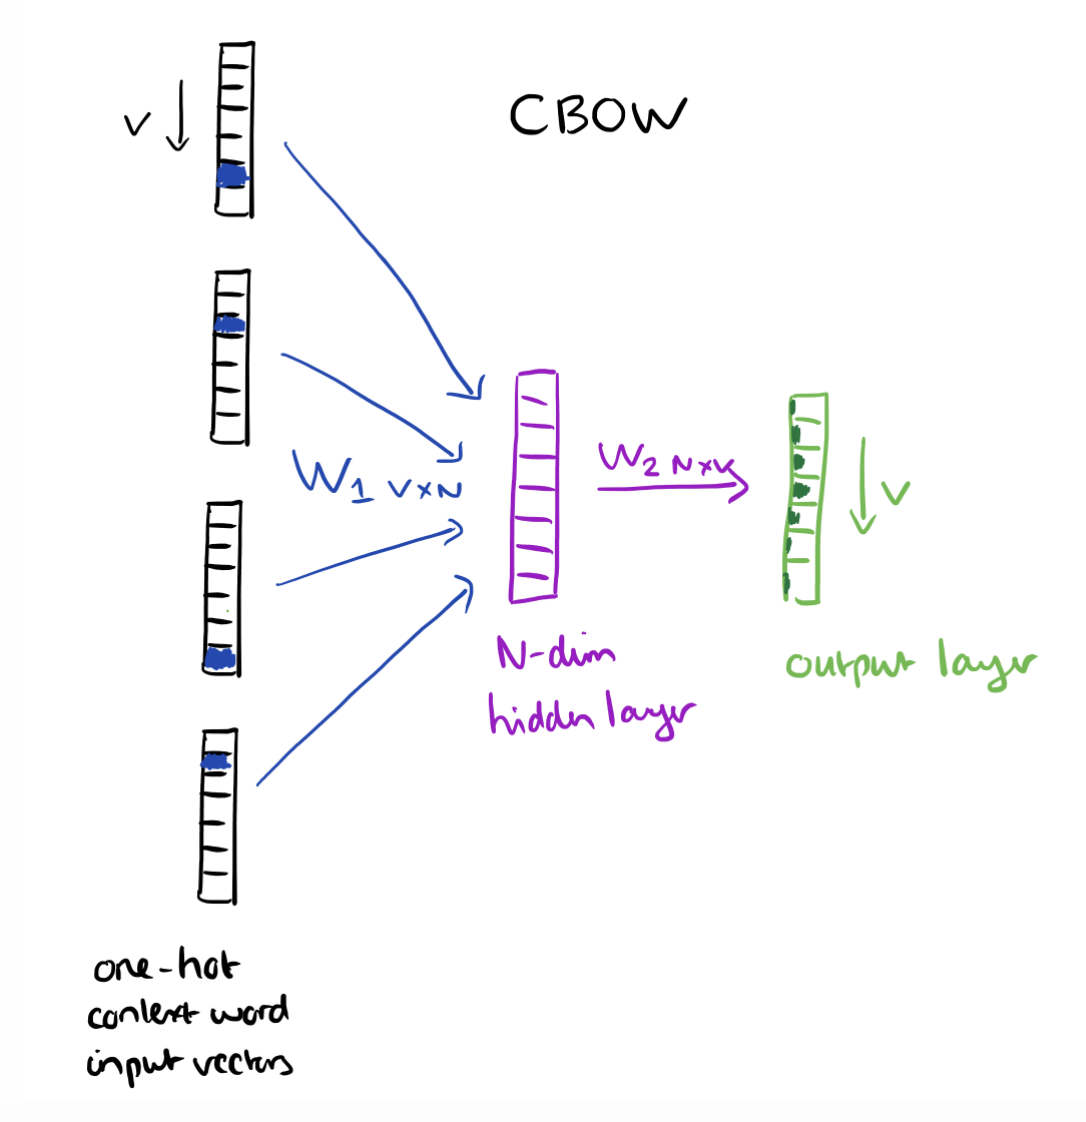

### CBOW vs Skip-gram architectures

- **CBOW (Continuous Bag of Words)** predicts the centre word from its context window.
- **Skip-gram** predicts the surrounding context words from the centre word.
The diagram below highlights the different information flow directions.

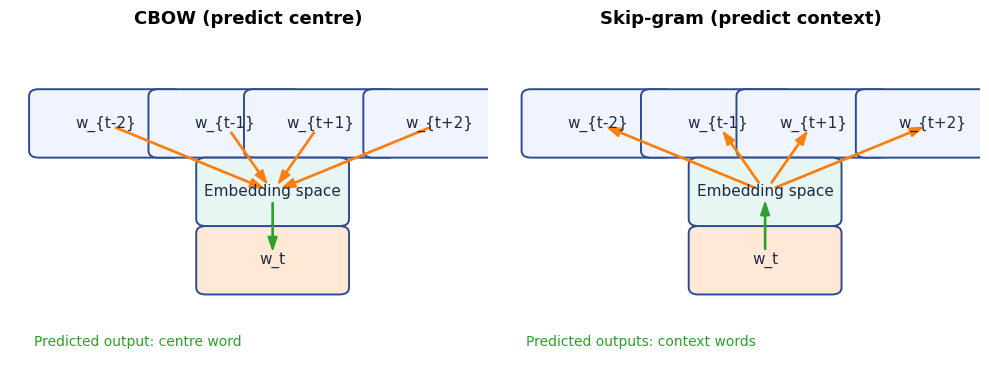

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def add_token_box(ax, center, text, color="#f0f4ff"):
    width, height = 0.28, 0.16
    x, y = center[0] - width / 2, center[1] - height / 2
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02",
        linewidth=1.4,
        edgecolor="#2f4b8f",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(center[0], center[1], text, ha="center", va="center", fontsize=11, color="#1f2a44")


def add_arrow(ax, start, end, color="#ff7f0e"):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="Simple,tail_width=0.5,head_width=6,head_length=9",
        color=color,
        linewidth=1.4,
        shrinkA=8,
        shrinkB=8,
    )
    ax.add_patch(arrow)


def draw_word2vec_architecture(ax, title, mode="cbow"):
    ax.set_title(title, fontsize=13, pad=10, fontweight="bold")
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    context_positions = [
        (0.2, 0.75),
        (0.45, 0.75),
        (0.65, 0.75),
        (0.9, 0.75),
    ]
    context_tokens = ["w_{t-2}", "w_{t-1}", "w_{t+1}", "w_{t+2}"]
    center_pos = (0.55, 0.35)
    center_token = "w_t"

    for pos, token in zip(context_positions, context_tokens):
        add_token_box(ax, pos, token)

    add_token_box(ax, center_pos, center_token, color="#ffe9d6")

    hidden_pos = (0.55, 0.55)
    add_token_box(ax, hidden_pos, "Embedding space", color="#e7f6f2")

    if mode == "cbow":
        for pos in context_positions:
            add_arrow(ax, pos, hidden_pos)
        add_arrow(ax, hidden_pos, center_pos, color="#2ca02c")
        ax.text(
            0.05,
            0.1,
            "Predicted output: centre word",
            fontsize=10,
            color="#2ca02c",
        )
    else:  # skip-gram
        add_arrow(ax, center_pos, hidden_pos, color="#2ca02c")
        for pos in context_positions:
            add_arrow(ax, hidden_pos, pos)
        ax.text(
            0.05,
            0.1,
            "Predicted outputs: context words",
            fontsize=10,
            color="#2ca02c",
        )


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_word2vec_architecture(axes[0], "CBOW (predict centre)", mode="cbow")
draw_word2vec_architecture(axes[1], "Skip-gram (predict context)", mode="skipgram")
plt.tight_layout()
plt.show()


Skip-gram often performs better on rare words.

## Training pipeline checklist

1. Collect a corpus and clean the text (remove HTML, punctuation, etc.).
2. Tokenise sentences into lists of words/subwords.
3. Feed token sequences into Word2Vec (window size, vector dimension, epochs are key hyperparameters).
4. Evaluate by inspecting nearest neighbours, analogies, and intrinsic metrics.
5. Export embeddings to reuse in downstream models or applications.

## Dataset

We will use the Quora Question Pairs dataset (two CSV splits `quora_01` and `quora_02`). Each row contains two questions that may or may not be semantically duplicate. The rich variety of question phrasing gives us a realistic corpus for learning embeddings.

The code below automatically:

1. Looks for the files in `.../01ADS/data`, `./data`, or `../data`.
2. When the files are missing (e.g., on Google Colab), downloads them from the GitHub repository `francji1/01ADS`.

In [31]:
import importlib
import subprocess
import sys


def ensure_package(module_name, pip_name=None):
    """Import a module, installing it via pip when necessary."""
    try:
        importlib.import_module(module_name)
    except ImportError:
        package = pip_name or module_name
        print(f"Installing {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


REQUIRED_PACKAGES = {
    "gensim": None,
    "sklearn": "scikit-learn",
    "transformers": None,
    "torch": None,
    "matplotlib": None,
}

for module_name, pip_name in REQUIRED_PACKAGES.items():
    ensure_package(module_name, pip_name)


In [32]:
import importlib
import sys
from pathlib import Path

shadow_dir = Path.cwd() / 'transformers'
if shadow_dir.exists() and not (shadow_dir / '__init__.py').exists():
    print("Detected local 'transformers' folder; adjusting import order to use Hugging Face package.")
    shadow_resolved = shadow_dir.resolve()
    cleaned_path = []
    for entry in sys.path:
        try:
            if Path(entry).resolve() == shadow_resolved:
                continue
        except Exception:
            pass
        cleaned_path.append(entry)
    sys.path = cleaned_path

transformers = importlib.import_module('transformers')
module_path = getattr(transformers, '__file__', 'namespace')
module_version = getattr(transformers, '__version__', 'unknown')
print('Using transformers v{} from {}'.format(module_version, module_path))


Detected local 'transformers' folder; adjusting import order to use Hugging Face package.
Using transformers v4.57.1 from c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\__init__.py


In [33]:
from pathlib import Path
import os
import random
import re

import numpy as np
import pandas as pd

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import torch
from transformers import AutoModel, AutoTokenizer


In [34]:
from urllib.request import urlretrieve

GITHUB_BASE_URL = "https://raw.githubusercontent.com/francji1/01ADS/main/data/"

DATA_DIR_CANDIDATES = [
    Path("M:/01ADS/01ADS/data"),
    Path.cwd() / "data",
    Path.cwd().parent / "data",
]


def resolve_data_file(filename):
    """Return a local path to `filename`, downloading it from GitHub if necessary."""
    for root in DATA_DIR_CANDIDATES:
        candidate = root / filename
        if candidate.exists():
            print(f"Using local copy: {candidate}")
            return candidate

    target_dir = Path.cwd() / "data"
    target_dir.mkdir(parents=True, exist_ok=True)
    url = f"{GITHUB_BASE_URL}{filename}"
    destination = target_dir / filename
    print(f"Downloading {url} -> {destination}")
    urlretrieve(url, destination)
    return destination


def read_csv_with_fallback(path, encodings=("utf-8", "utf-8-sig", "cp1250", "latin-1")):
    """Load a CSV trying multiple encodings to accommodate different environments."""
    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError as exc:
            print(f"Retrying {path} with encoding={encoding}")
            last_error = exc
    if last_error:
        raise last_error
    raise ValueError("No encodings attempted when reading CSV.")


def load_quora_dataframe():
    files = ["quora_01.csv", "quora_02.csv"]
    frames = []
    for fname in files:
        path = resolve_data_file(fname)
        frames.append(read_csv_with_fallback(path))
    df = pd.concat(frames, ignore_index=True)
    df = df.dropna(subset=["question1", "question2"])
    df = df.drop_duplicates(subset=["question1", "question2"])
    df["question1"] = df["question1"].astype(str)
    df["question2"] = df["question2"].astype(str)
    print(f"Loaded {len(df):,} question pairs.")
    return df.reset_index(drop=True)


quora_df = load_quora_dataframe()
quora_df.head()


Using local copy: M:\01ADS\01ADS\data\quora_01.csv
Retrying M:\01ADS\01ADS\data\quora_01.csv with encoding=utf-8
Retrying M:\01ADS\01ADS\data\quora_01.csv with encoding=utf-8-sig
Retrying M:\01ADS\01ADS\data\quora_01.csv with encoding=cp1250
Using local copy: M:\01ADS\01ADS\data\quora_02.csv
Retrying M:\01ADS\01ADS\data\quora_02.csv with encoding=utf-8
Retrying M:\01ADS\01ADS\data\quora_02.csv with encoding=utf-8-sig
Retrying M:\01ADS\01ADS\data\quora_02.csv with encoding=cp1250
Loaded 385,314 question pairs.


,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


The Quora dataset contains the columns  `question1`, `question2`, and `is_duplicate`. We keep only the text columns for unsupervised embedding training.

In [35]:
def sentence_generator(df, text_columns=("question1", "question2"), max_sentences=40000):
    """Yield tokenised sentences for Word2Vec training."""
    emitted = 0
    for column in text_columns:
        for text in df[column]:
            tokens = simple_preprocess(text)
            if tokens:
                yield tokens
                emitted += 1
                if max_sentences and emitted >= max_sentences:
                    return


MAX_SENTENCES = 100000
sentences = list(sentence_generator(quora_df, max_sentences=MAX_SENTENCES))
print(f"Prepared {len(sentences)} sentences for training (max={MAX_SENTENCES}).")
sentences[:3]


Prepared 100000 sentences for training (max=100000).


[['what',
  'is',
  'the',
  'step',
  'by',
  'step',
  'guide',
  'to',
  'invest',
  'in',
  'share',
  'market',
  'in',
  'india'],
 ['what', 'is', 'the', 'story', 'of', 'kohinoor', 'koh', 'noor', 'diamond'],
 ['how',
  'can',
  'increase',
  'the',
  'speed',
  'of',
  'my',
  'internet',
  'connection',
  'while',
  'using',
  'vpn']]

We cap the corpus at 100k sentences so that training remains quick in class while still showing meaningful structure.

In [36]:
WORD2VEC_PARAMS = {
    "vector_size": 150,
    "window": 5,
    "min_count": 3,
    "workers": max(2, os.cpu_count() or 2),
    "sg": 1,  # skip-gram
    "negative": 10,
    "epochs": 8,
}

w2v_model = Word2Vec(sentences=sentences, **WORD2VEC_PARAMS)
w2v_model


Skip-gram focuses on predicting context words from a centre word, which tends to model rare words better. Hyperparameters like `vector_size`, `window`, and `min_count` are great discussion points—challenge students to experiment.

In [37]:
def print_nearest_words(model, target_words, topn=8):
    for word in target_words:
        if word in model.wv:
            neighbours = model.wv.most_similar(word, topn=topn)
            print(f"\nNearest to '{word}':")
            for neighbour, score in neighbours:
                print(f"  {neighbour:<20} {score:.3f}")
        else:
            print(f"\n'{word}' is not in the vocabulary.")


probe_words = ["question", "university", "python", "bank", "love"]
print_nearest_words(w2v_model, probe_words)



Nearest to 'question':
  answer               0.762
  questions            0.738
  marking              0.660
  flagged              0.658
  upvote               0.656
  answering            0.655
  asked                0.654
  collapsed            0.651

Nearest to 'university':
  nit                  0.726
  admission            0.709
  mit                  0.709
  calcutta             0.693
  yale                 0.693
  caltech              0.692
  undergraduate        0.692
  vit                  0.686

Nearest to 'python':
  javascript           0.871
  django               0.831
  java                 0.810
  php                  0.809
  beginners            0.803
  angularjs            0.798
  js                   0.795
  node                 0.793

Nearest to 'bank':
  sbi                  0.706
  icici                0.687
  savings              0.674
  hdfc                 0.663
  paypal               0.629
  idbi                 0.622
  debit                0.620
  banks  

In [38]:
def show_analogy(model, positive, negative):
    try:
        result = model.wv.most_similar(positive=positive, negative=negative, topn=1)
        word, score = result[0]
        print(f"{positive} minus {negative} → {word} ({score:.3f})")
    except KeyError as exc:
        print(f"Missing words: {exc}")


analogy_examples = [
    (["king", "woman"], ["queen"]),
    (["rome", "france"], ["italy"]),
    (["programming", "teacher"], ["student"]),
]

for positives, negatives in analogy_examples:
    show_analogy(w2v_model, positives, negatives)


['king', 'woman'] minus ['queen'] → man (0.646)
['rome', 'france'] minus ['italy'] → soviet (0.753)
['programming', 'teacher'] minus ['student'] → languages (0.601)


In [39]:
# What should not be there? 
print(w2v_model.wv.doesnt_match(['tesla', 'bmw', 'superman', 'mercedes']))
print(w2v_model.wv.doesnt_match(['trump', 'president', 'wall', 'business']))

superman
business


Analogy results reveal where the model succeeds or fails—prompt a discussion about vocabulary coverage, biases, and when analogies break down.

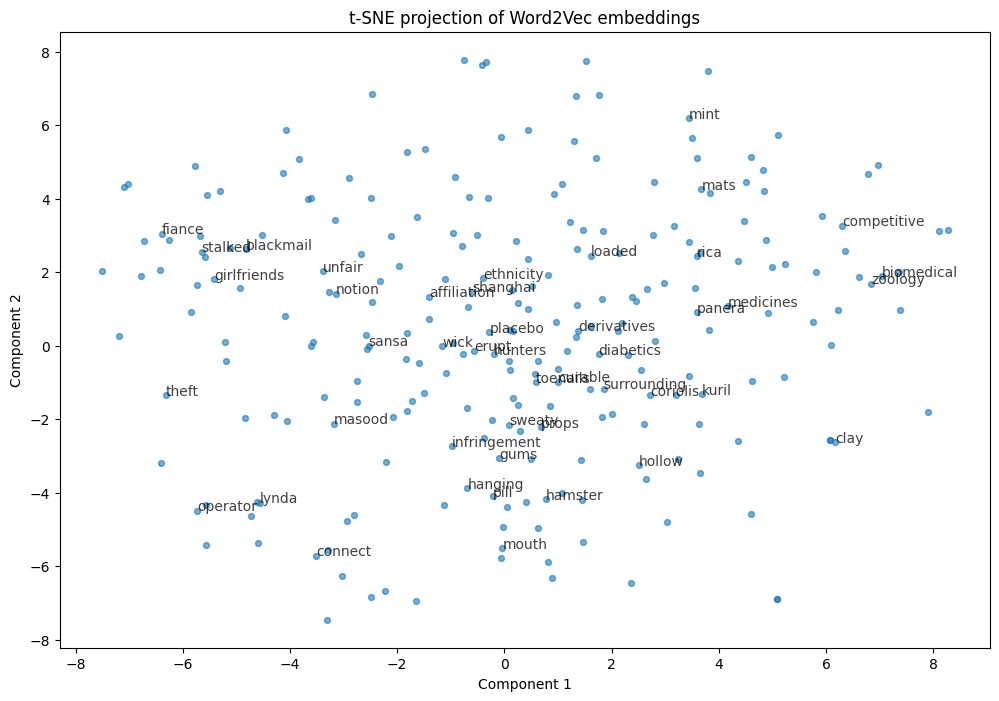

In [40]:
#random.seed(4242)

sampled_words = [
    word
    for word in w2v_model.wv.key_to_index.keys()
    if word.isalpha() and 4 <= len(word) <= 12
]

sampled_words = random.sample(sampled_words, k=min(250, len(sampled_words)))
embeddings_matrix = np.vstack([w2v_model.wv[word] for word in sampled_words])

tsne = TSNE(
    n_components=2,
    #random_state=42,
    init="random",
    learning_rate="auto",
    perplexity=30,
)
embedding_2d = tsne.fit_transform(embeddings_matrix)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=18, alpha=0.6)
for idx, word in enumerate(sampled_words[:45]):
    plt.annotate(word, (embedding_2d[idx, 0], embedding_2d[idx, 1]), alpha=0.75)
plt.title("t-SNE projection of Word2Vec embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


## From word to sentence embeddings

- Word2Vec gives us token-level vectors; sentence meaning can be approximated by averaging word vectors.
- This ignores word order and polysemy but is still useful for quick similarity checks.
- Transformers learn contextual embeddings that specialise each token based on the entire sentence.

In [41]:
def embed_sentence_word2vec(sentence, model):
    tokens = simple_preprocess(sentence)
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


w2v_sample_sentences = [
    "How can I learn Python quickly?",
    "What are the best resources to master Python fast?",
    "How do I bake a chocolate cake without eggs?",
    "Why is the sky blue?",
]

w2v_sentence_vectors = np.vstack(
    [embed_sentence_word2vec(sentence, w2v_model) for sentence in w2v_sample_sentences]
)

pd.DataFrame(
    cosine_similarity(w2v_sentence_vectors),
    index=w2v_sample_sentences,
    columns=w2v_sample_sentences,
)


,How can I learn Python quickly?,What are the best resources to master Python fast?,How do I bake a chocolate cake without eggs?,Why is the sky blue?
How can I learn Python quickly?,1.000000,0.787288,0.734311,0.478114
What are the best resources to master Python fast?,0.787288,1.000000,0.648895,0.589528
How do I bake a chocolate cake without eggs?,0.734311,0.648895,1.000000,0.604775
Why is the sky blue?,0.478114,0.589528,0.604775,1.000000


Notice how the first two questions cluster together, while the cooking and physics questions stand apart—that is the geometric signal we rely on for search.

## Using Pre-trained Embeddings (GloVe)

Training on the Quora corpus gives us domain-tuned Word2Vec vectors. For a broader vocabulary or when compute is limited, we can load pre-trained embeddings such as `glove-wiki-gigaword-50` distributed through `gensim.downloader` or grab similar artefacts from HuggingFace hubs. Below we compare neighbourhoods and sentence similarities between our Quora Word2Vec model and the off-the-shelf GloVe vectors.

Glove
https://en.wikipedia.org/wiki/GloVe

# GloVe – Global Vectors for Word Representation

**What it is.** GloVe is a count-based method that learns **static word embeddings** by factorizing the **global word–context co-occurrence** statistics of a corpus. Unlike predictive models (e.g., Word2Vec SGNS), GloVe directly fits word vectors to approximate the **log co-occurrence** values.

**Objective.**
Let $X_{ij}$ be the number of times context word $j$ appears near word $i$. GloVe minimizes a weighted squared error:
$$
\min_{w,\tilde w,b,\tilde b}\;\sum_{i,j} f(X_{ij})\Big(w_i^\top \tilde w_j + b_i+\tilde b_j - \log X_{ij}\Big)^2,
$$
with a weighting function
$$
f(x)=
\begin{cases}
\left(\frac{x}{x_{\max}}\right)^{\alpha} & x < x_{\max},\\[2pt]
1 & \text{otherwise},
\end{cases}
$$
typically $\alpha = 3/4$. The final word vector is often $w_i + \tilde w_i$.

**Properties.**
- Static embeddings (one vector per word), typical dims **50–300**.
- Captures global corpus statistics; fast to train on CPUs/GPUs.
- No subword handling; polysemy not resolved (same vector for all senses).


In [42]:
import gensim.downloader as api

try:
    glove_vectors
except NameError:
    print("Loading pre-trained 'glove-wiki-gigaword-50' vectors...")
    glove_vectors = api.load("glove-wiki-gigaword-50")

glove_vectors


In [43]:
def print_nearest_words_from_vectors(vectors, target_words, topn=8):
    for word in target_words:
        if word in vectors.key_to_index:
            neighbours = vectors.most_similar(word, topn=topn)
            print(f"\nNearest to '{word}' in {getattr(vectors, 'name', 'pre-trained')} (top {topn}):")
            for neighbour, score in neighbours:
                print(f"  {neighbour:<20} {score:.3f}")
        else:
            print(f"\n'{word}' is missing from the vocabulary.")


comparison_words = probe_words if 'probe_words' in globals() else ["question", "university", "python", "bank", "love"]
print_nearest_words_from_vectors(glove_vectors, comparison_words)



Nearest to 'question' in pre-trained (top 8):
  answer               0.924
  what                 0.905
  whether              0.903
  fact                 0.893
  explain              0.886
  questions            0.883
  reason               0.883
  matter               0.880

Nearest to 'university' in pre-trained (top 8):
  college              0.874
  harvard              0.871
  yale                 0.857
  graduate             0.855
  institute            0.848
  professor            0.842
  school               0.826
  faculty              0.826

Nearest to 'python' in pre-trained (top 8):
  reticulated          0.692
  spamalot             0.664
  php                  0.641
  owl                  0.630
  mouse                0.628
  reticulatus          0.627
  perl                 0.627
  monkey               0.621

Nearest to 'bank' in pre-trained (top 8):
  banks                0.870
  securities           0.800
  banking              0.797
  investment           0.785
  ex

In [44]:
comparison_rows = []
for word in comparison_words:
    row = {"word": word}
    if word in w2v_model.wv:
        row["Word2Vec (Quora)"] = ", ".join(
            neighbour for neighbour, _ in w2v_model.wv.most_similar(word, topn=5)
        )
    else:
        row["Word2Vec (Quora)"] = "n/a"
    if word in glove_vectors.key_to_index:
        row["GloVe Wiki-Gigaword 50"] = ", ".join(
            neighbour for neighbour, _ in glove_vectors.most_similar(word, topn=5)
        )
    else:
        row["GloVe Wiki-Gigaword 50"] = "n/a"
    comparison_rows.append(row)

pd.DataFrame(comparison_rows).set_index("word")


,Word2Vec (Quora),GloVe Wiki-Gigaword 50
word,,
question,"answer, questions, marking, flagged, upvote","answer, what, whether, fact, explain"
university,"nit, admission, mit, calcutta, yale","college, harvard, yale, graduate, institute"
python,"javascript, django, java, php, beginners","reticulated, spamalot, php, owl, mouse"
bank,"sbi, icici, savings, hdfc, paypal","banks, securities, banking, investment, exchange"
love,"loved, deeply, madly, loves, uncomfortable","dream, life, dreams, loves, me"


In [45]:
def embed_sentence_keyed_vectors(sentence, vectors):
    tokens = simple_preprocess(sentence)
    token_vecs = [vectors[word] for word in tokens if word in vectors.key_to_index]
    if not token_vecs:
        return np.zeros(vectors.vector_size)
    return np.mean(token_vecs, axis=0)


glove_sentence_vectors = np.vstack(
    [embed_sentence_keyed_vectors(sentence, glove_vectors) for sentence in w2v_sample_sentences]
)

glove_similarity = pd.DataFrame(
    cosine_similarity(glove_sentence_vectors),
    index=w2v_sample_sentences,
    columns=w2v_sample_sentences,
)

print("Sentence-level cosine similarities with GloVe embeddings:")
glove_similarity


Sentence-level cosine similarities with GloVe embeddings:


,How can I learn Python quickly?,What are the best resources to master Python fast?,How do I bake a chocolate cake without eggs?,Why is the sky blue?
How can I learn Python quickly?,1.000000,0.912908,0.742270,0.793707
What are the best resources to master Python fast?,0.912908,1.000000,0.682173,0.870965
How do I bake a chocolate cake without eggs?,0.742270,0.682173,1.000000,0.665156
Why is the sky blue?,0.793707,0.870965,0.665156,1.000000


In [46]:
pairwise_diff = glove_similarity - pd.DataFrame(
    cosine_similarity(w2v_sentence_vectors),
    index=w2v_sample_sentences,
    columns=w2v_sample_sentences,
)

pairwise_diff.style.background_gradient(cmap="coolwarm", axis=None).format("{:+.3f}")


,How can I learn Python quickly?,What are the best resources to master Python fast?,How do I bake a chocolate cake without eggs?,Why is the sky blue?
How can I learn Python quickly?,-0.000,+0.126,+0.008,+0.316
What are the best resources to master Python fast?,+0.126,-0.000,+0.033,+0.281
How do I bake a chocolate cake without eggs?,+0.008,+0.033,+0.000,+0.060
Why is the sky blue?,+0.316,+0.281,+0.060,+0.000


Positive values (red) indicate pairs that become more similar with GloVe than with our Quora Word2Vec; negative values (blue) show the opposite. This highlights how corpus choice shifts embedding geometry.

## Encoder, Decoder, and Encoder-Decoder Families

Language architectures fall into three broad groups:
- **Encoder-only** models consume an input sequence and produce contextualised representations. Typical examples include BERT, RoBERTa, and DistilBERT.
- **Decoder-only** models generate the next token given everything seen so far. These causal models excel at open-ended generation. GPT-2/3/4 and LLaMA families are decoder-only.
- **Encoder-decoder** (seq2seq) models map an input sequence into a latent representation with the encoder, then decode into a target sequence. They power translation, summarisation, and instruction-tuned assistants. T5, Whisper, ....

| Architecture | Typical training objective | Strengths | Example models |
| --- | --- | --- | --- |
| Encoder-only | Masked language modelling / contrastive objectives | Rich semantic embeddings, retrieval, classification | BERT, RoBERTa, DeBERTa |
| Decoder-only | Next-token prediction (causal) | Long-form generation, code synthesis, chat | GPT, LLaMA, Phi |
| Encoder-decoder | Seq2seq with cross-attention | Translation, summarisation, grounded generation | T5, BART, Whisper |

When building LLM applications, we often mix these blocks. For embeddings we use encoder stacks; for generation we reach for decoders or full encoder-decoder pipelines.

### Hands-on: contextual encoder vs Word2Vec and GloVe

Let us embed the same question set with an open encoder (`all-MiniLM-L6-v2`) and compare cosine similarities against our Quora-trained Word2Vec and the pre-trained GloVe vectors.

In [47]:
if "TRANSFORMER_MODEL_NAME" not in globals():
    TRANSFORMER_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "tokenizer" not in globals() or getattr(tokenizer, "name_or_path", None) != TRANSFORMER_MODEL_NAME:
    tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

if "transformer_model" not in globals() or getattr(transformer_model.config, "_name_or_path", None) != TRANSFORMER_MODEL_NAME:
    transformer_model = AutoModel.from_pretrained(TRANSFORMER_MODEL_NAME)
    print(f"Loaded {TRANSFORMER_MODEL_NAME}.")
else:
    print(f"Reusing cached model {TRANSFORMER_MODEL_NAME}.")

transformer_model = transformer_model.to(device)
if device.type == "cuda":
    device_index = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(device_index)
    print(f"Using CUDA device {device_index}: {device_name}")
else:
    print("CUDA not available; using CPU fallback.")

device


Reusing cached model sentence-transformers/all-MiniLM-L6-v2.
CUDA not available; using CPU fallback.


device(type='cpu')

In [48]:
if "mean_pooling" not in globals():
    def mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    def encode_sentences(sentences, batch_size=16):
        embeddings = []
        for start in range(0, len(sentences), batch_size):
            batch = sentences[start : start + batch_size]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=256,
                return_tensors="pt",
            )
            encoded = {key: value.to(device) for key, value in encoded.items()}
            with torch.no_grad():
                model_output = transformer_model(**encoded)
            sentence_embeddings = mean_pooling(model_output, encoded["attention_mask"])
            sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)
            embeddings.append(sentence_embeddings.cpu().numpy())
        return np.vstack(embeddings)
else:
    print("encode_sentences helper already present.")


encode_sentences helper already present.


In [49]:
encoder_sentence_vectors = encode_sentences(w2v_sample_sentences)
print(f"MiniLM sentence embeddings shape: {encoder_sentence_vectors.shape}")

embedding_preview = (
    pd.DataFrame(encoder_sentence_vectors, index=w2v_sample_sentences)
    .iloc[:, :8]
    .round(3)
)
embedding_preview


MiniLM sentence embeddings shape: (4, 384)


,0,1,2,3,4,5,6,7
How can I learn Python quickly?,0.027,0.010,0.007,0.064,-0.017,-0.054,-0.025,-0.009
What are the best resources to master Python fast?,-0.022,-0.021,-0.000,0.044,0.008,-0.084,-0.058,-0.007
How do I bake a chocolate cake without eggs?,0.034,0.051,-0.025,0.075,-0.020,0.027,-0.021,-0.052
Why is the sky blue?,0.010,-0.002,0.050,0.047,0.055,0.009,0.105,-0.026


In [50]:
w2v_similarity_matrix = cosine_similarity(w2v_sentence_vectors)
glove_similarity_matrix = cosine_similarity(glove_sentence_vectors)
encoder_similarity_matrix = cosine_similarity(encoder_sentence_vectors)

encoder_similarity_df = pd.DataFrame(
    encoder_similarity_matrix,
    index=w2v_sample_sentences,
    columns=w2v_sample_sentences,
)
print("Sentence-level cosine similarities with MiniLM encoder:")
display(encoder_similarity_df)

comparison_rows = []
for i in range(len(w2v_sample_sentences)):
    for j in range(i + 1, len(w2v_sample_sentences)):
        comparison_rows.append(
            {
                "sentence_a": w2v_sample_sentences[i],
                "sentence_b": w2v_sample_sentences[j],
                "Word2Vec (Quora)": w2v_similarity_matrix[i, j],
                "GloVe Wiki-Gigaword 50": glove_similarity_matrix[i, j],
                "MiniLM encoder": encoder_similarity_matrix[i, j],
            }
        )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["most_similar_model"] = comparison_df[
    ["Word2Vec (Quora)", "GloVe Wiki-Gigaword 50", "MiniLM encoder"]
].idxmax(axis=1)

comparison_df.sort_values(by="MiniLM encoder", ascending=False)


Sentence-level cosine similarities with MiniLM encoder:


,How can I learn Python quickly?,What are the best resources to master Python fast?,How do I bake a chocolate cake without eggs?,Why is the sky blue?
How can I learn Python quickly?,1.000000,0.752851,0.019011,-0.030805
What are the best resources to master Python fast?,0.752851,1.000000,0.034036,-0.028182
How do I bake a chocolate cake without eggs?,0.019011,0.034036,1.000000,0.080299
Why is the sky blue?,-0.030805,-0.028182,0.080299,1.000000


,sentence_a,sentence_b,Word2Vec (Quora),GloVe Wiki-Gigaword 50,MiniLM encoder,most_similar_model
0,How can I learn Python quickly?,What are the best resources to master Python f...,0.787288,0.912908,0.752851,GloVe Wiki-Gigaword 50
5,How do I bake a chocolate cake without eggs?,Why is the sky blue?,0.604775,0.665156,0.080299,GloVe Wiki-Gigaword 50
3,What are the best resources to master Python f...,How do I bake a chocolate cake without eggs?,0.648895,0.682173,0.034036,GloVe Wiki-Gigaword 50
1,How can I learn Python quickly?,How do I bake a chocolate cake without eggs?,0.734311,0.742270,0.019011,GloVe Wiki-Gigaword 50
4,What are the best resources to master Python f...,Why is the sky blue?,0.589528,0.870965,-0.028182,GloVe Wiki-Gigaword 50
2,How can I learn Python quickly?,Why is the sky blue?,0.478114,0.793707,-0.030805,GloVe Wiki-Gigaword 50


We now see three similarity scores for every pair of questions. Word2Vec (Quora) emphasises phrasing that co-occurs in the dataset, GloVe reflects broader news/web statistics, and the MiniLM encoder captures higher-level semantics thanks to deep self-attention. Flag the rows where `most_similar_model` flips�those are great discussion points when motivating contextual embeddings.

## Enter transformers

We will use the lightweight `sentence-transformers/all-MiniLM-L6-v2` model.

In [51]:
print(f"Transformers demo running on device: {device}")

Transformers demo running on device: cpu


In [52]:
if "mean_pooling" not in globals():
    def mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    def encode_sentences(sentences, batch_size=16):
        embeddings = []
        for start in range(0, len(sentences), batch_size):
            batch = sentences[start : start + batch_size]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=256,
                return_tensors="pt",
            )
            encoded = {key: value.to(device) for key, value in encoded.items()}
            with torch.no_grad():
                model_output = transformer_model(**encoded)
            sentence_embeddings = mean_pooling(model_output, encoded["attention_mask"])
            sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)
            embeddings.append(sentence_embeddings.cpu().numpy())
        return np.vstack(embeddings)
else:
    print("encode_sentences helper already present.")


encode_sentences helper already present.


In [53]:
transformer_sample_sentences = [
    "How can I learn Python quickly?",
    "What are the best resources to master Python fast?",
    "How do I bake a chocolate cake without eggs?",
    "Why is the sky blue?",
    "Is Java or Python better for web development?",
]

transformer_vectors = encode_sentences(transformer_sample_sentences)

similarity_df = pd.DataFrame(
    cosine_similarity(transformer_vectors),
    index=transformer_sample_sentences,
    columns=transformer_sample_sentences,
)

similarity_df


,How can I learn Python quickly?,What are the best resources to master Python fast?,How do I bake a chocolate cake without eggs?,Why is the sky blue?,Is Java or Python better for web development?
How can I learn Python quickly?,1.000000,0.752851,0.019011,-0.030805,0.401885
What are the best resources to master Python fast?,0.752851,1.000000,0.034036,-0.028182,0.430285
How do I bake a chocolate cake without eggs?,0.019011,0.034036,1.000000,0.080299,-0.011986
Why is the sky blue?,-0.030805,-0.028182,0.080299,1.000000,0.080256
Is Java or Python better for web development?,0.401885,0.430285,-0.011986,0.080256,1.000000


The transformer captures deeper nuances: programming-related questions cluster, and unrelated topics remain distant. Compare these scores with the earlier Word2Vec matrix.

## Vector databases and retrieval (Next Lesson)

- A vector database stores embeddings for fast similarity search (Faiss, Milvus, Pinecone, etc.).
- Retrieval-Augmented Generation (RAG) = embed documents → store vectors → embed a query → retrieve neighbours → feed to an LLM.
- This bridges traditional IR and generative models, grounding answers in curated knowledge.

In [54]:
def build_vector_index(questions, encoder, n_neighbors=5):
    vectors = encoder(questions)
    index = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine")
    index.fit(vectors)
    return index, vectors


rag_corpus = quora_df["question1"].dropna().sample(n=250, random_state=42).tolist()
vector_index, rag_vectors = build_vector_index(rag_corpus, encode_sentences, n_neighbors=5)


def search_similar_questions(query, top_k=5):
    query_vector = encode_sentences([query])[0]
    distances, indices = vector_index.kneighbors([query_vector], n_neighbors=top_k)
    results = []
    for distance, idx in zip(distances[0], indices[0]):
        results.append((rag_corpus[idx], distance))
    return results


query = "How can I prepare for a data science interview?"
for rank, (question, distance) in enumerate(search_similar_questions(query), start=1):
    print(f"{rank}. ({distance:.3f}) {question}")


1. (0.557) What are the best excuses to reset a time for a job interview?
2. (0.571) Which are the topics one has to revise before going for a design engineer interview as a fresher and an experienced one as well?
3. (0.666) How do I know that I can become a good IAS officer?
4. (0.695) I am a 2016 B.E in EEE and I am looking for software job in Bangalore, how to secure a job?
5. (0.696) How can I start learning?
